In [1]:
from mace.calculators import MACECalculator
import numpy as np

import matplotlib.pyplot as plt

from ase.visualize import view
from ase.build import graphene

/home/gabrielecolombo/Thesis/PROJECT/new_sources/mace_custom/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/home/gabrielecolombo/Thesis/PROJECT/new_sources/mace_custom/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1488: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
atoms = graphene(a=2.459829)
view(atoms, viewer='x3d')

In [3]:
import subprocess
ROOT = subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip()

MODELPATH=f"{ROOT}/mace/NP1000_trigold_merged/swa/swalong/checkpoints/MACE_v0_run-1009_epoch-45_swa.model"
calc = MACECalculator(MODELPATH, device="cuda")
atoms.calc = calc
atoms.cell[2][2] = 100

/home/gabrielecolombo/Thesis/PROJECT/new_sources/mace_custom/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using head Default out of ['Default']
No dtype selected, switching to float32 to match model dtype.


/home/gabrielecolombo/Thesis/PROJECT/new_sources/mace_custom/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/gabrielecolombo/Thesis/PROJECT/new_sources/mace_custom/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/gabrielecolombo/Thesis/PROJECT/new_sources/mace_custom/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


### optimize structure

In [4]:
from ase.optimize import BFGS
from ase.filters import FrechetCellFilter

filter = FrechetCellFilter(atoms, mask = [1,1,0,0,0,0])
opt = BFGS(filter)
opt.run(fmax=1e-5)

atoms = atoms.repeat((10, 10,1))
atoms.calc = calc
view(atoms, viewer='x3d')

      Step     Time          Energy          fmax
BFGS:    0 13:51:39      -18.151257        0.201136
BFGS:    1 13:51:39      -18.151697        0.029076
BFGS:    2 13:51:39      -18.151709        0.000029
BFGS:    3 13:51:39      -18.151709        0.000013
BFGS:    4 13:51:39      -18.151709        0.000014
BFGS:    5 13:51:39      -18.151709        0.000018
BFGS:    6 13:51:39      -18.151707        0.000018
BFGS:    7 13:51:39      -18.151709        0.000001


In [5]:
i0=0
i1=1
p0 = atoms.positions[0]
p1=atoms.positions[1]

nndistance = np.linalg.norm(p1 - p0)
print("neirest neighbor distance:", nndistance)

neirest neighbor distance: 1.4225702634758979


## Change positions of i0 and i1 atoms and measure potential energy

- Due to the environment, I expect the energy to change in a non trivial way.
- There are 4 independent variables to change.
- There are some simmetries.
- I choose center of mass, oriantation and relative distance as coordinates

In [6]:
CM = (p1 + p0)/2.
ANGLE=0
D=nndistance

print("CM:", CM)
print("ANGLE:", ANGLE)
print("D", D)

CM: [6.15990984e-01 3.55642562e-01 1.25736761e-20]
ANGLE: 0
D 1.4225702634758979


In [7]:
from tqdm import tqdm

# ---- scan parameters ----
d_values = np.linspace(D*0.8, D*2.0, 100)
angle_values = np.linspace(0, np.pi/2, 100)

# storage
distances = []
angles = []
energies = []
forces0 = []
forces1 = []

# reference geometry
base_positions = atoms.get_positions().copy()

# bond direction
v0 = base_positions[1] - base_positions[0]
v0 = v0 / np.linalg.norm(v0)

for d in tqdm(d_values):

    for angle in angle_values:

        pos = base_positions.copy()

        # rotation matrix (xy plane)
        rot = np.array([
            [np.cos(angle), -np.sin(angle), 0],
            [np.sin(angle),  np.cos(angle), 0],
            [0,0,1]
        ])

        v_rot = rot @ v0

        # keep center fixed
        pos[0] = CM - 0.5*d*v_rot
        pos[1] = CM + 0.5*d*v_rot

        atoms.set_positions(pos)

        # evaluation
        E = atoms.get_potential_energy()
        F = atoms.get_forces()

        distances.append(d)
        angles.append(angle)
        energies.append(E)
        forces0.append(F[0].copy())
        forces1.append(F[1].copy())

print("Computed points:", len(energies))


100%|██████████| 100/100 [04:52<00:00,  2.93s/it]

Computed points: 10000


In [34]:
from numpy import meshgrid

gridpoints = meshgrid(angle_values, d_values)

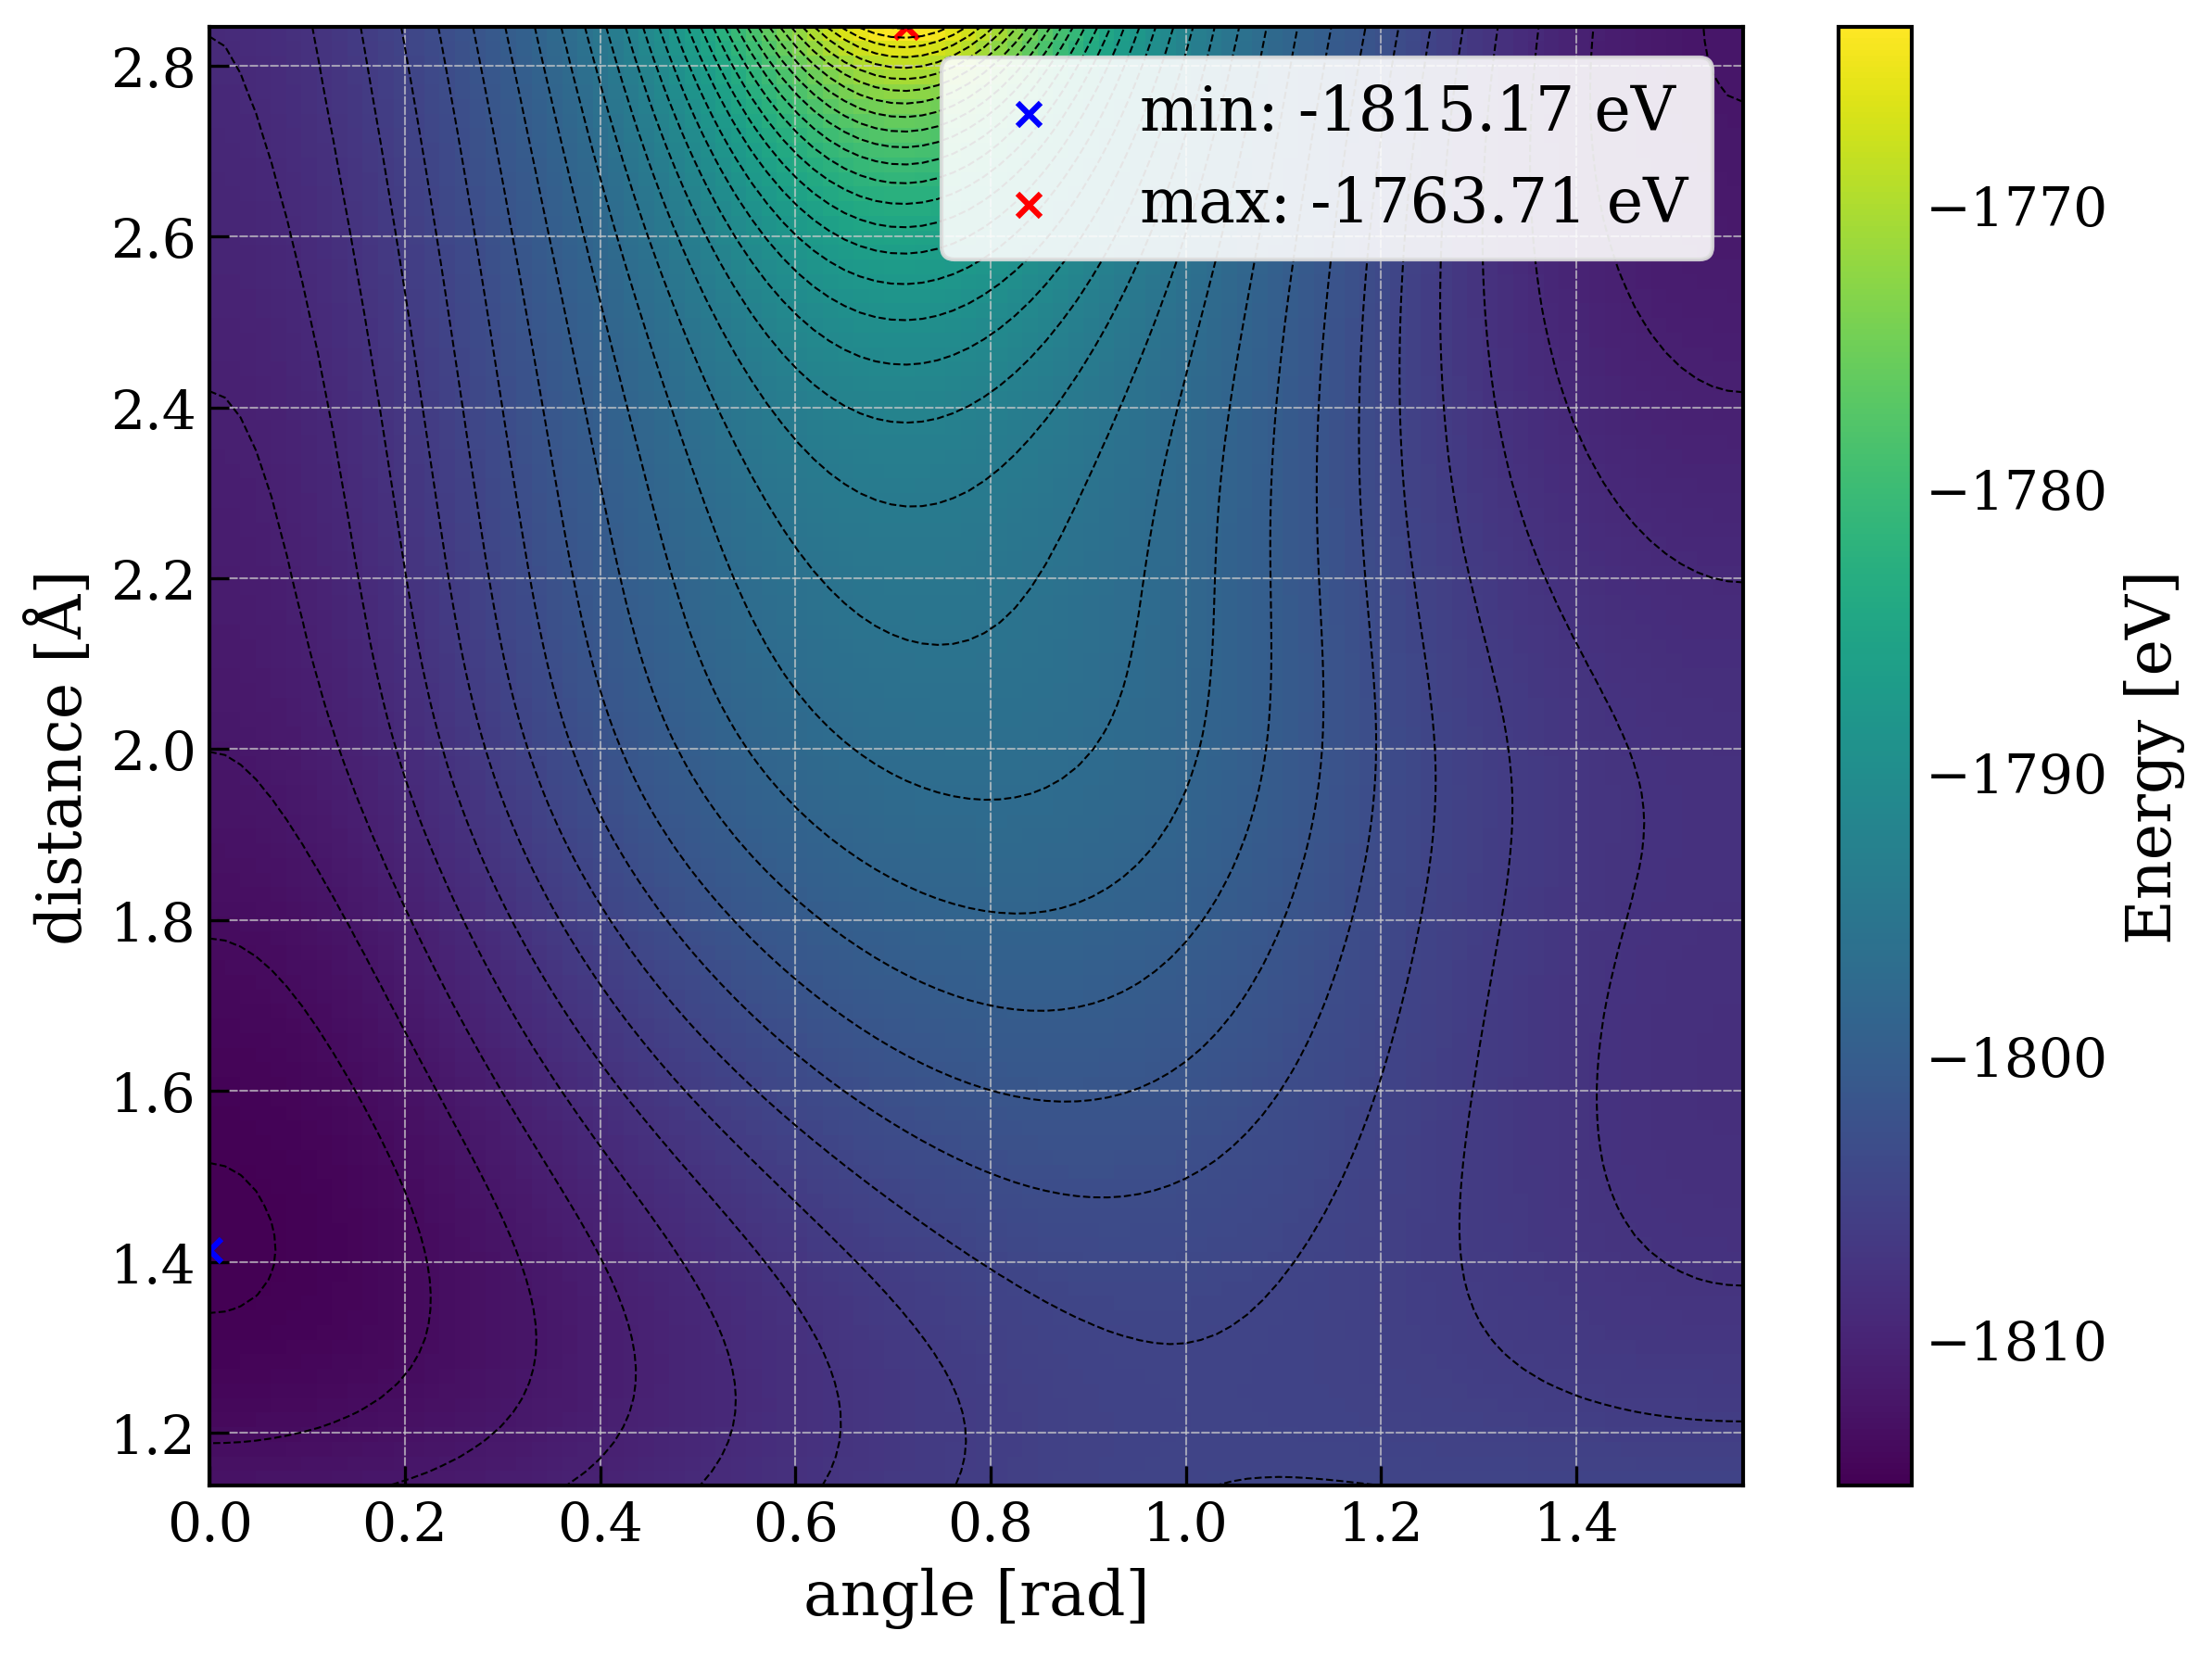

In [38]:
E_surface = np.array(energies).reshape(len(d_values), len(angle_values))
plt.imshow(E_surface, origin="lower",
           extent=[angle_values[0], angle_values[-1],
                   d_values[0], d_values[-1]],
           aspect="auto")
plt.colorbar(label="Energy [eV]")
plt.contour(angle_values, d_values, E_surface, colors="k", levels=50, linewidths=0.5)

mine_idx = np.argmin(E_surface)
mine = E_surface.flatten()[mine_idx]
maxe_idx = np.argmax(E_surface)
maxe = E_surface.flatten()[maxe_idx]
gridmin = gridpoints[0].flatten()[mine_idx], gridpoints[1].flatten()[mine_idx]
gridmax = gridpoints[0].flatten()[maxe_idx], gridpoints[1].flatten()[maxe_idx]
plt.scatter(gridmin[0], gridmin[1], marker = "x", color="blue", label=f"min: {mine:.2f} eV")
plt.scatter(gridmax[0], gridmax[1], marker = "x", color="red", label=f"max: {maxe:.2f} eV")

plt.xlabel("angle [rad]")
plt.ylabel("distance [Å]")
plt.legend()

plt.savefig("pe_grid.svg")
plt.show()

In [26]:
forces1 = np.array(forces1).reshape(len(d_values), len(angle_values), 3)
forces0 = np.array(forces0).reshape(len(d_values), len(angle_values), 3)

f0mod = np.linalg.norm(forces0, axis = -1)
f1mod = np.linalg.norm(forces1, axis = -1)


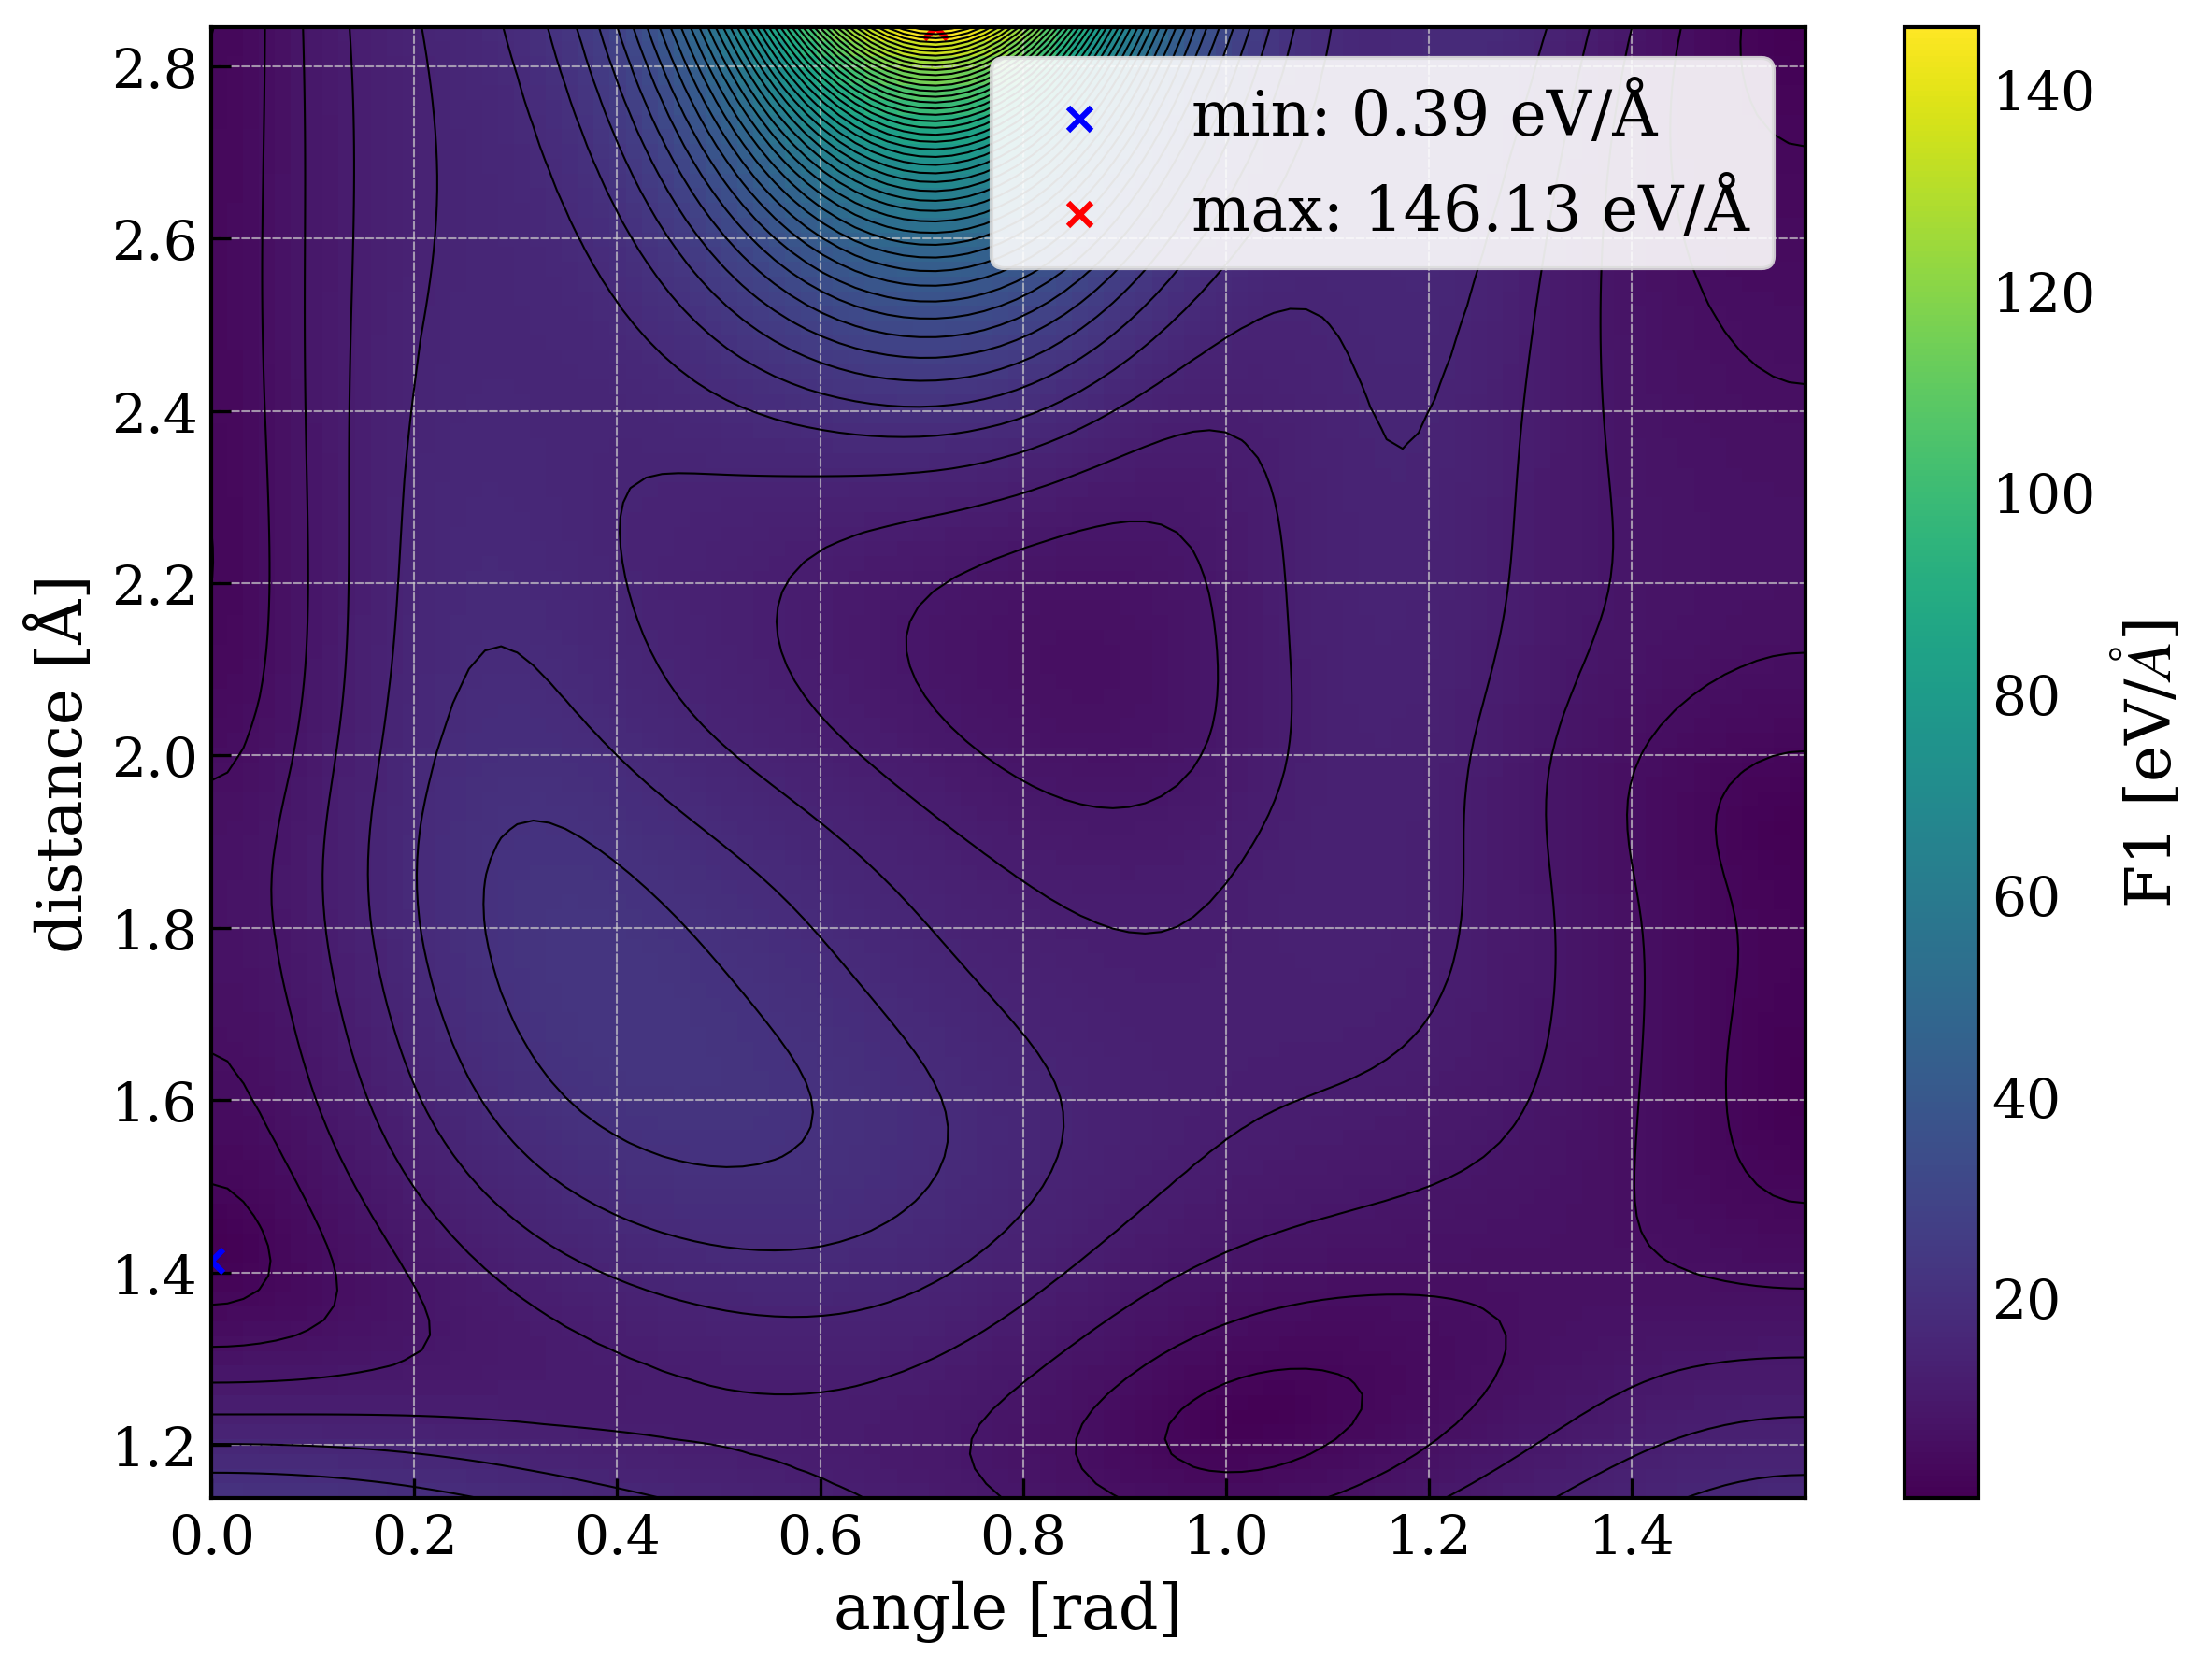

In [39]:
plt.imshow(f1mod[:,:], origin="lower",
           extent=[angle_values[0], angle_values[-1],
                   d_values[0], d_values[-1]],
           aspect="auto")

plt.colorbar(label=r"F1 [eV/$\AA$]")

plt.contour(angle_values, d_values, f1mod, colors="k", levels=50, linewidths=0.5)

gridmin = gridpoints[0].flatten()[mine_idx], gridpoints[1].flatten()[mine_idx]
gridmax = gridpoints[0].flatten()[maxe_idx], gridpoints[1].flatten()[maxe_idx]
plt.scatter(gridmin[0], gridmin[1], marker = "x", color="blue", label=f"min: {f1mod.flatten()[mine_idx]:.2f} eV/Å")
plt.scatter(gridmax[0], gridmax[1], marker = "x", color="red", label=f"max: {f1mod.flatten()[maxe_idx]:.2f} eV/Å")
plt.legend()    

plt.xlabel("angle [rad]")
plt.ylabel("distance [Å]")
plt.savefig("f1_grid.svg")
plt.show()

In [41]:
ND  = 500
DS = np.linspace(1.2, 3, num=ND)
Dforces0=[]
Dforces1=[]
Denergies=[]

for d in tqdm(DS):
    pos = base_positions.copy()

    # keep center fixed
    pos[0] = CM - 0.5*d*v0
    pos[1] = CM + 0.5*d*v0

    atoms.set_positions(pos)

    # evaluation
    E = atoms.get_potential_energy()
    F = atoms.get_forces()

    Denergies.append(E)
    Dforces0.append(F[0].copy())
    Dforces1.append(F[1].copy())

Dforces0=np.array(Dforces0).reshape((ND, 3))
Dforces1=np.array(Dforces1).reshape((ND, 3))
Denergies = np.array(Denergies)

100%|██████████| 500/500 [00:15<00:00, 33.04it/s]


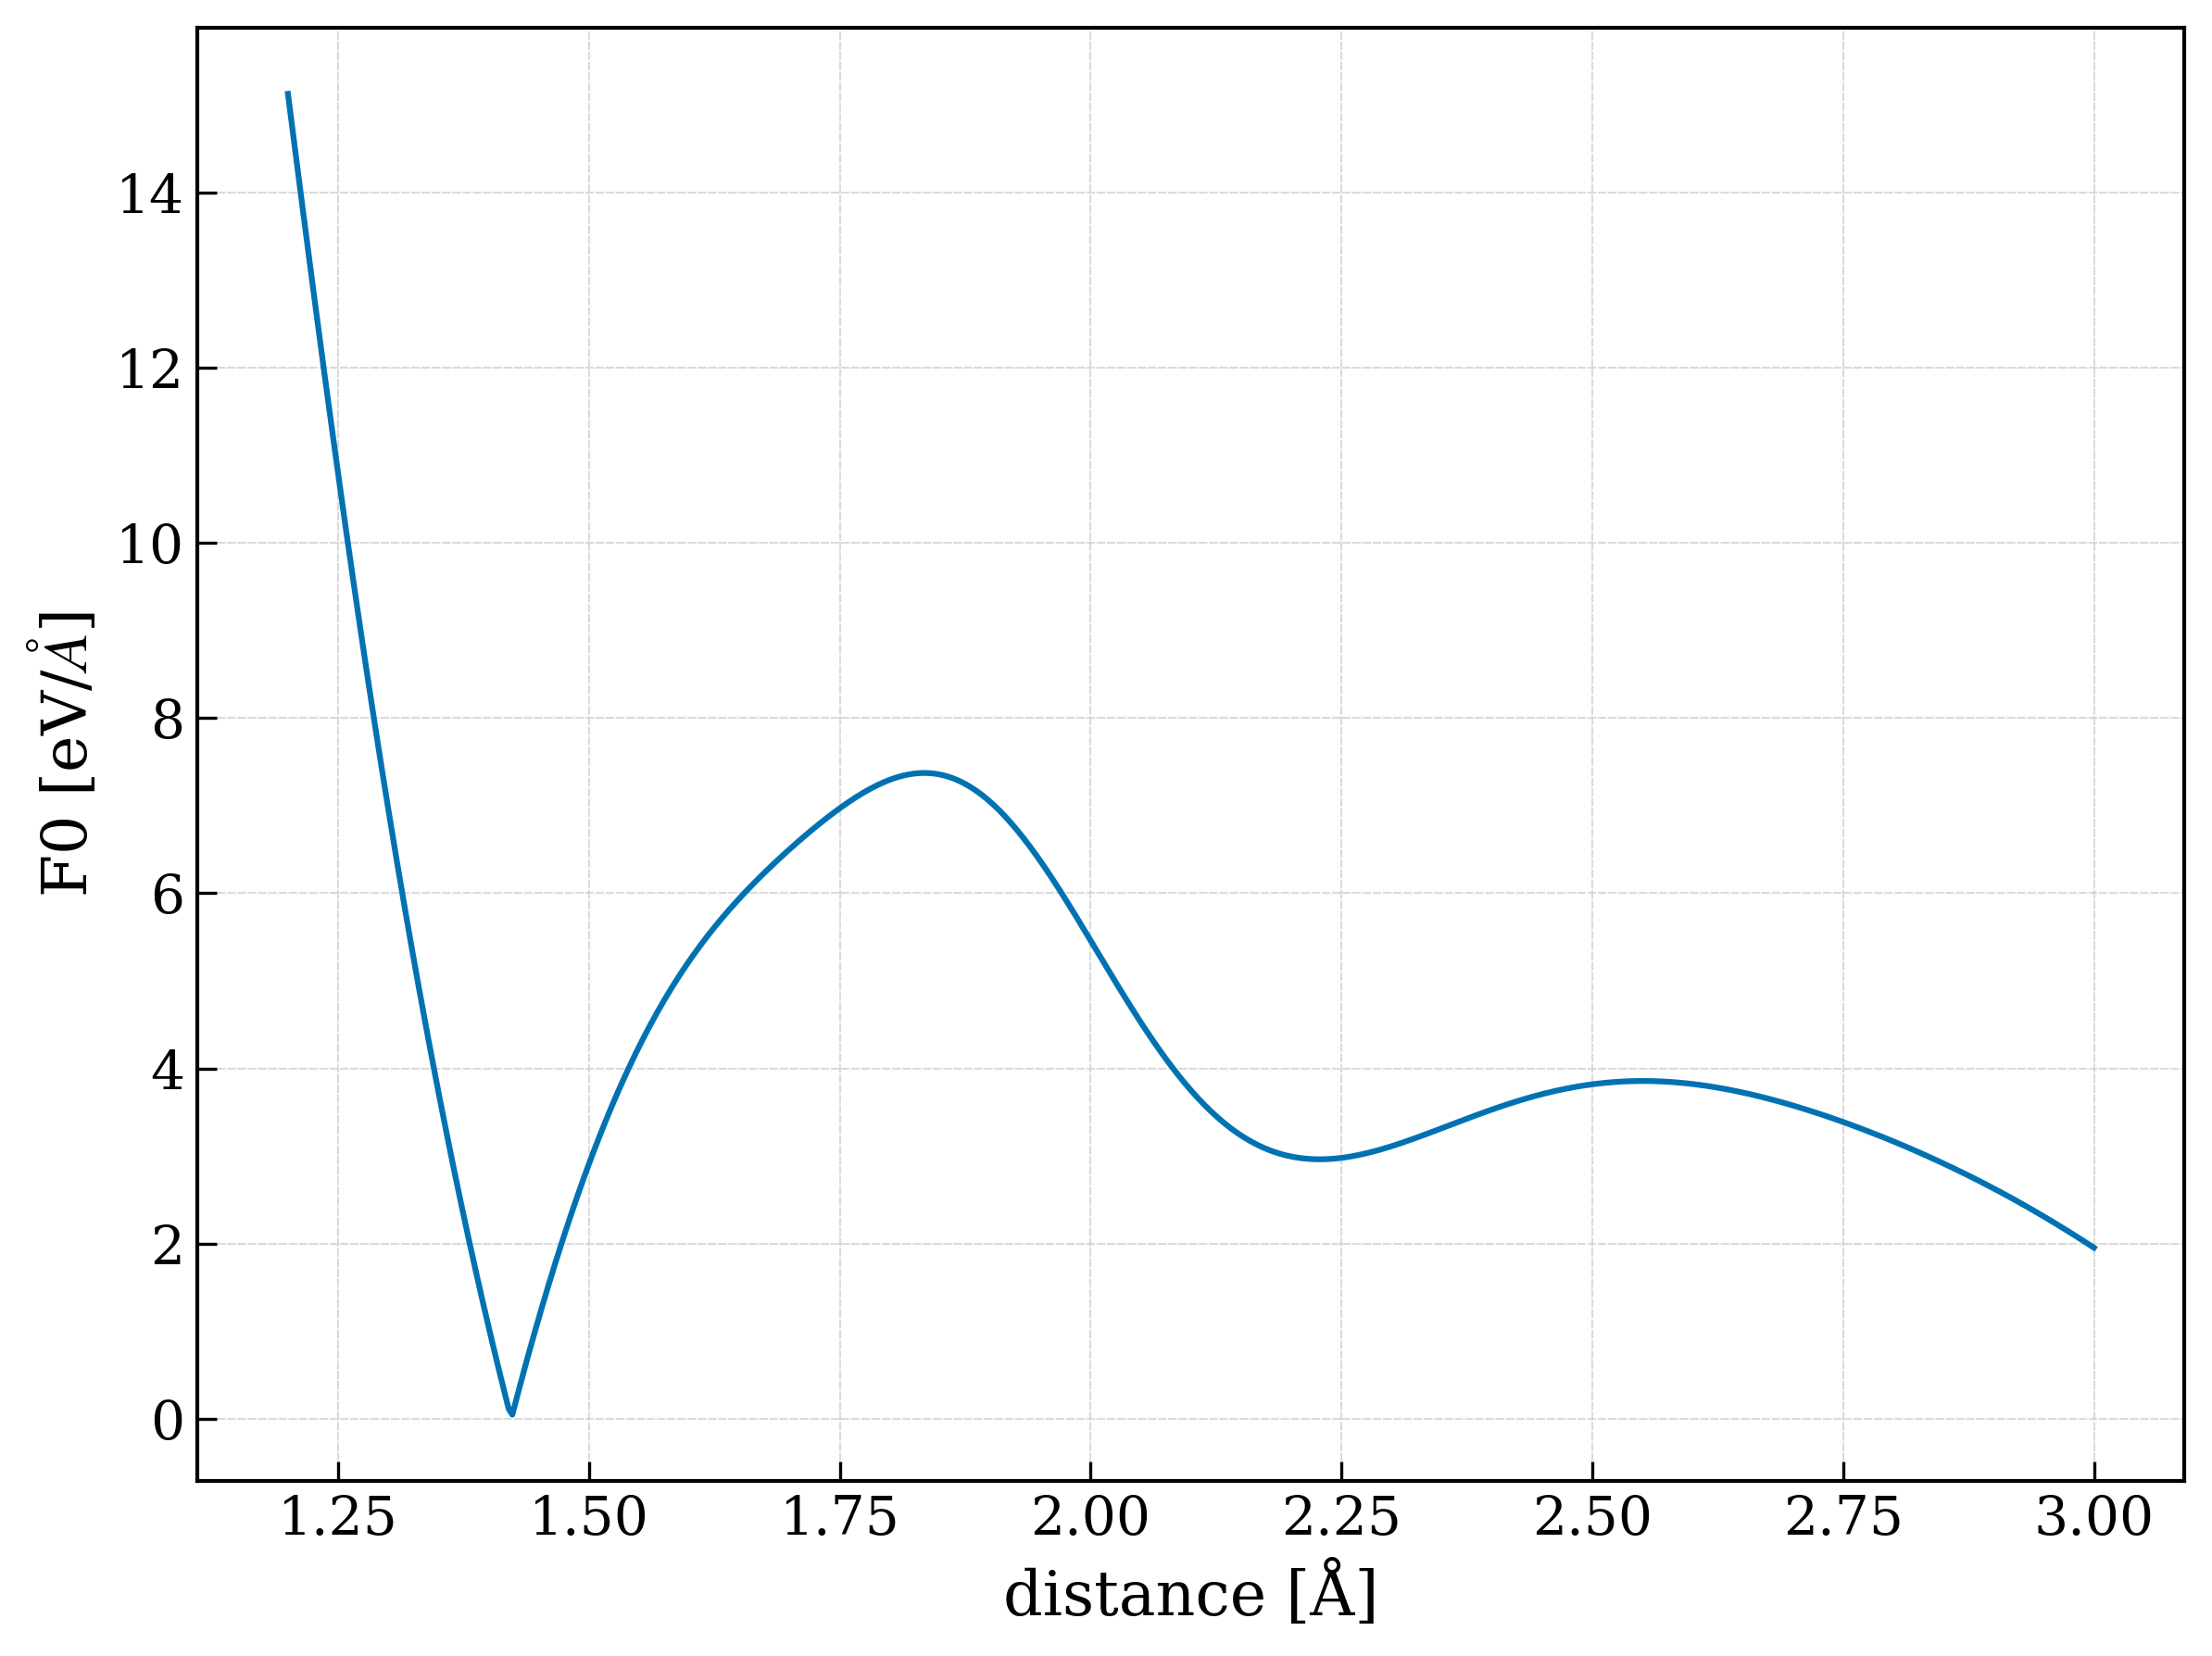

In [42]:
plt.plot(DS, np.linalg.norm(Dforces0, axis=-1))
plt.xlabel("distance [Å]")
plt.ylabel(r"F0 [eV/$\AA$]")
plt.savefig("f0_d.svg")
plt.show()

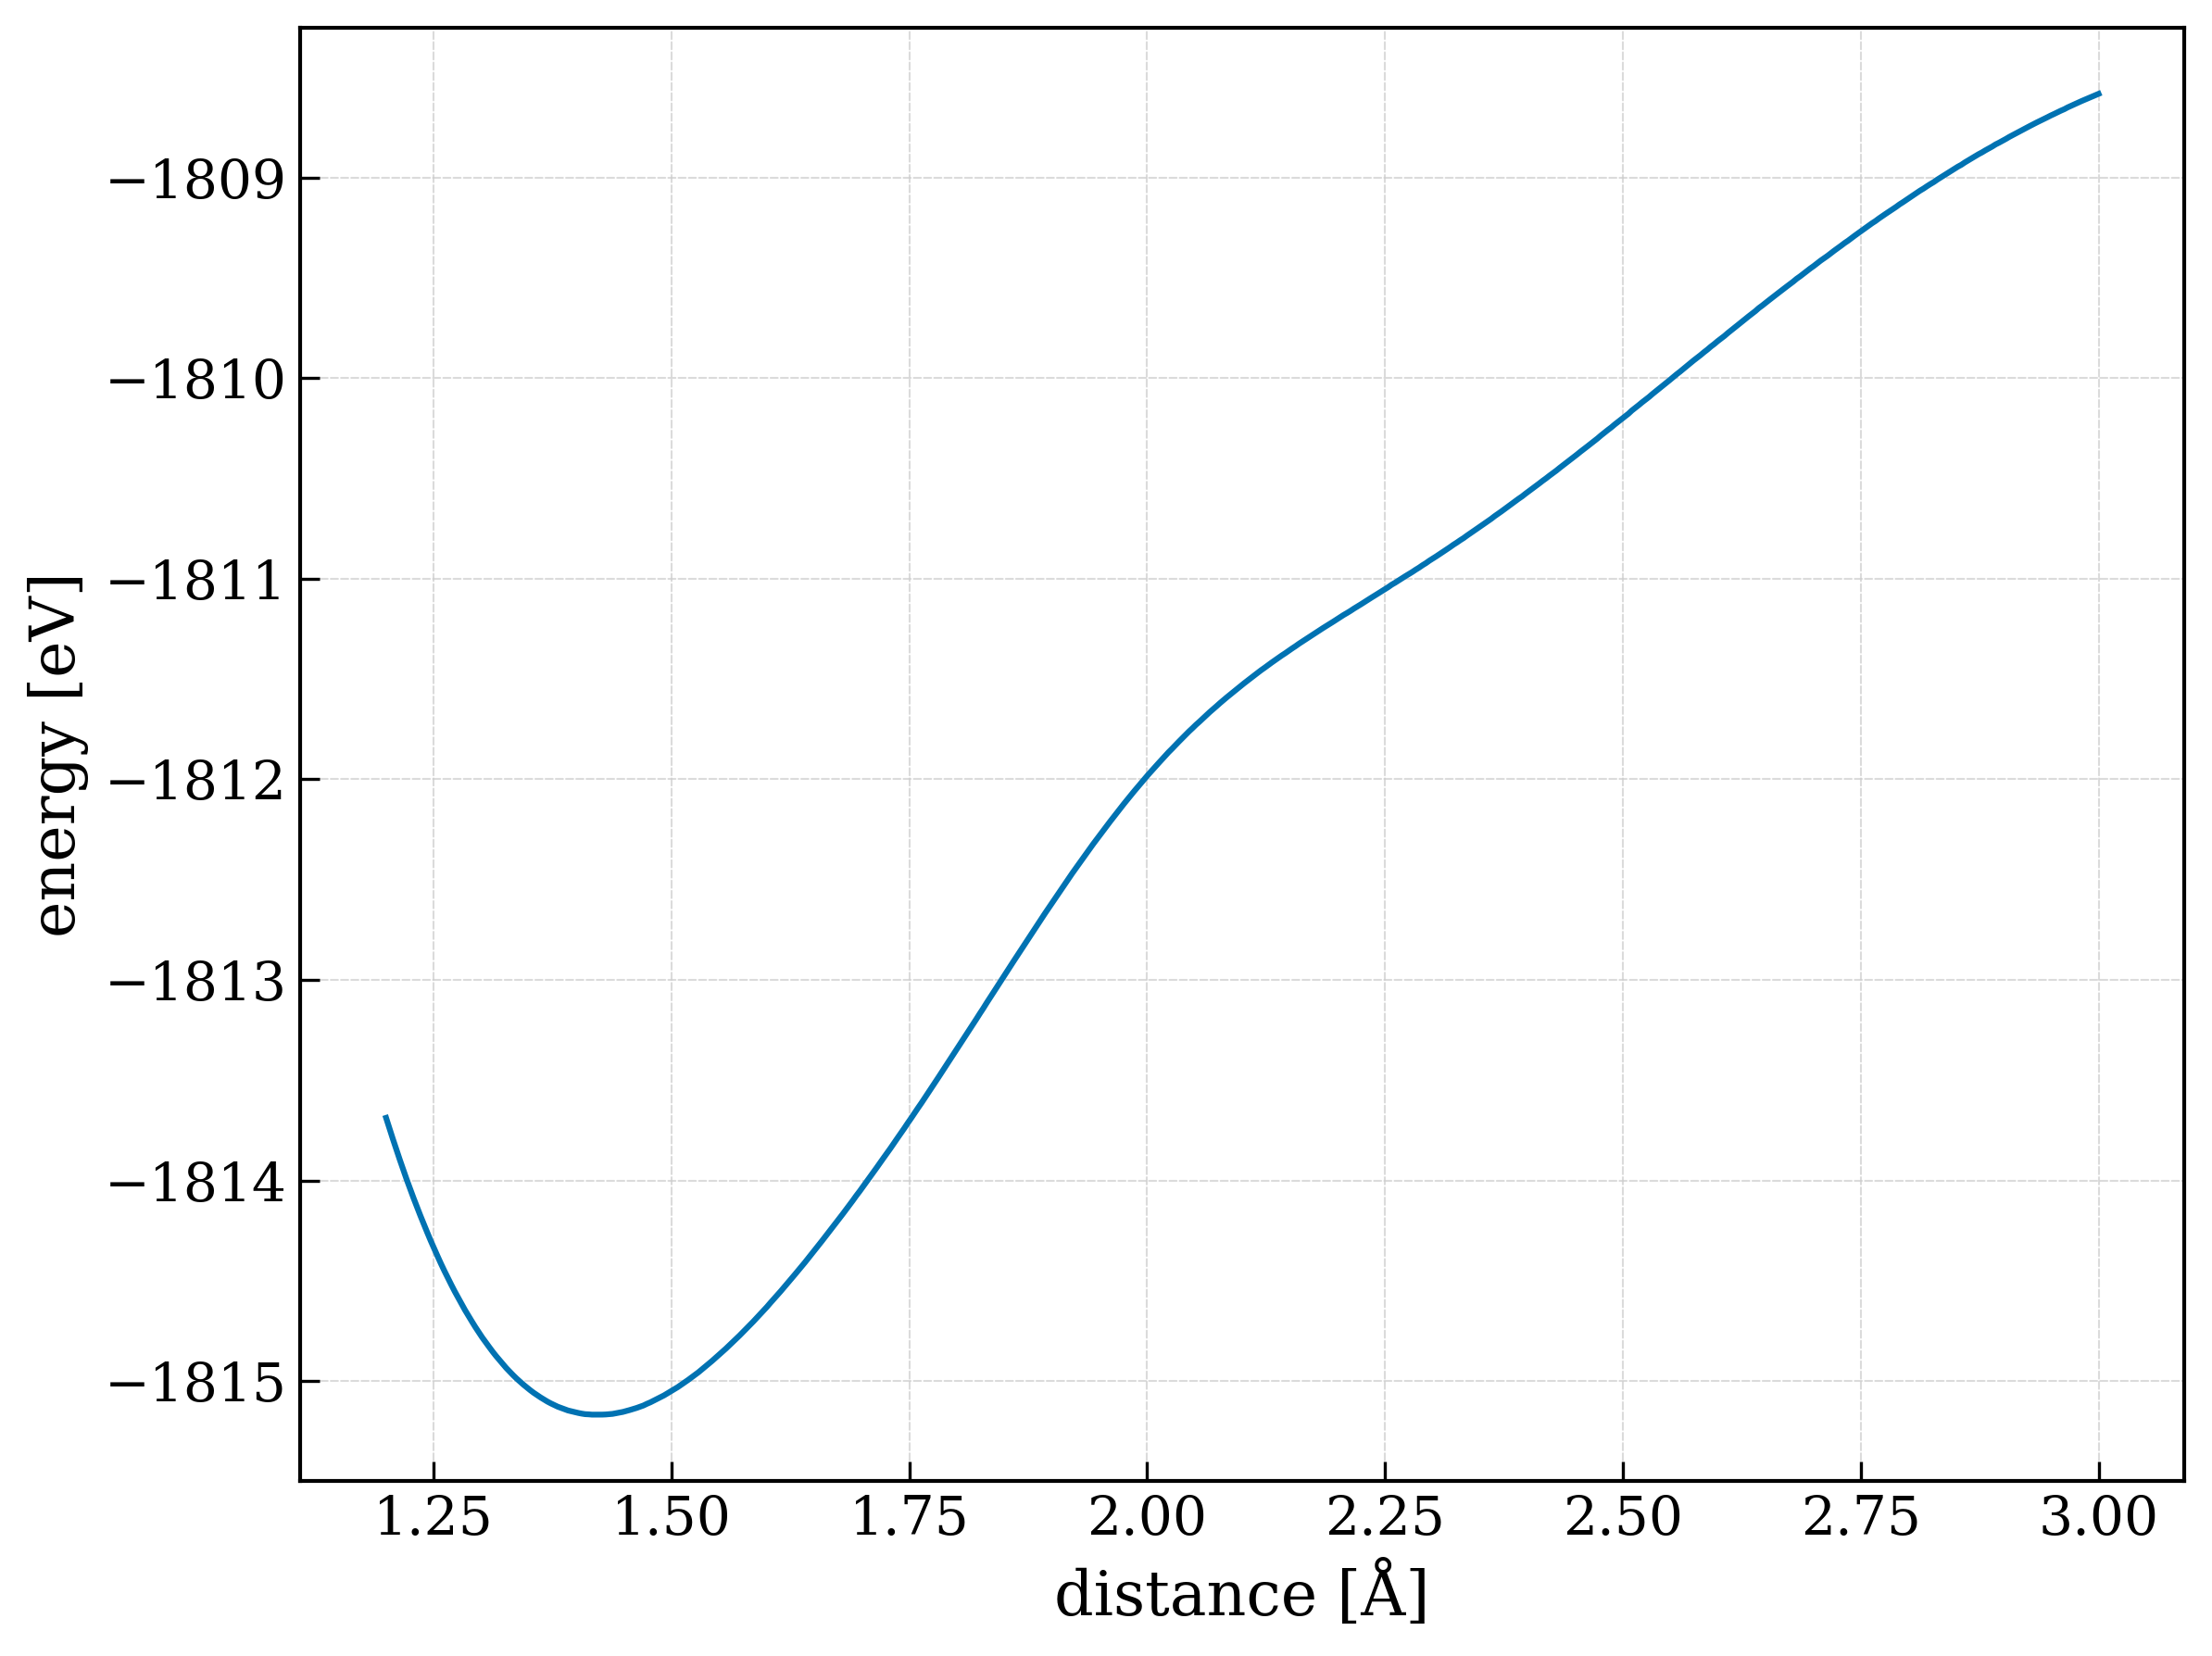

In [43]:
plt.plot(DS, Denergies)
plt.xlabel("distance [Å]")
plt.ylabel("energy [eV]")
plt.savefig("pe_d.svg")
plt.show()

## strained system

In [14]:
strain = np.array([[0.21, 0, 0], [0, 0, 0], [0, 0, 0]])
deformation = np.identity(3) + strain

In [15]:
strained_atoms = atoms.copy()
strained_atoms.positions = base_positions

cell = strained_atoms.cell.array.copy()
print(cell)

cell[0] *= deformation[0][0]   # stretch first lattice vector
print(cell)

strained_atoms.set_cell(cell, scale_atoms=True)
print(strained_atoms.cell)

strained_atoms.calc=calc
strained_positions = strained_atoms.positions.copy()

[[ 24.63963933   0.           0.        ]
 [-12.31981967  21.33855385   0.        ]
 [  0.           0.         100.        ]]
[[ 29.81396359   0.           0.        ]
 [-12.31981967  21.33855385   0.        ]
 [  0.           0.         100.        ]]
Cell([[29.81396359138602, 0.0, 0.0], [-12.319819665861992, 21.33855385367063, 0.0], [0.0, 0.0, 100.0]])


In [16]:
np.linalg.norm(strained_atoms.get_positions()[1] - strained_atoms.get_positions()[0])
distances = strained_atoms.get_all_distances()

(0.0, 2.0)

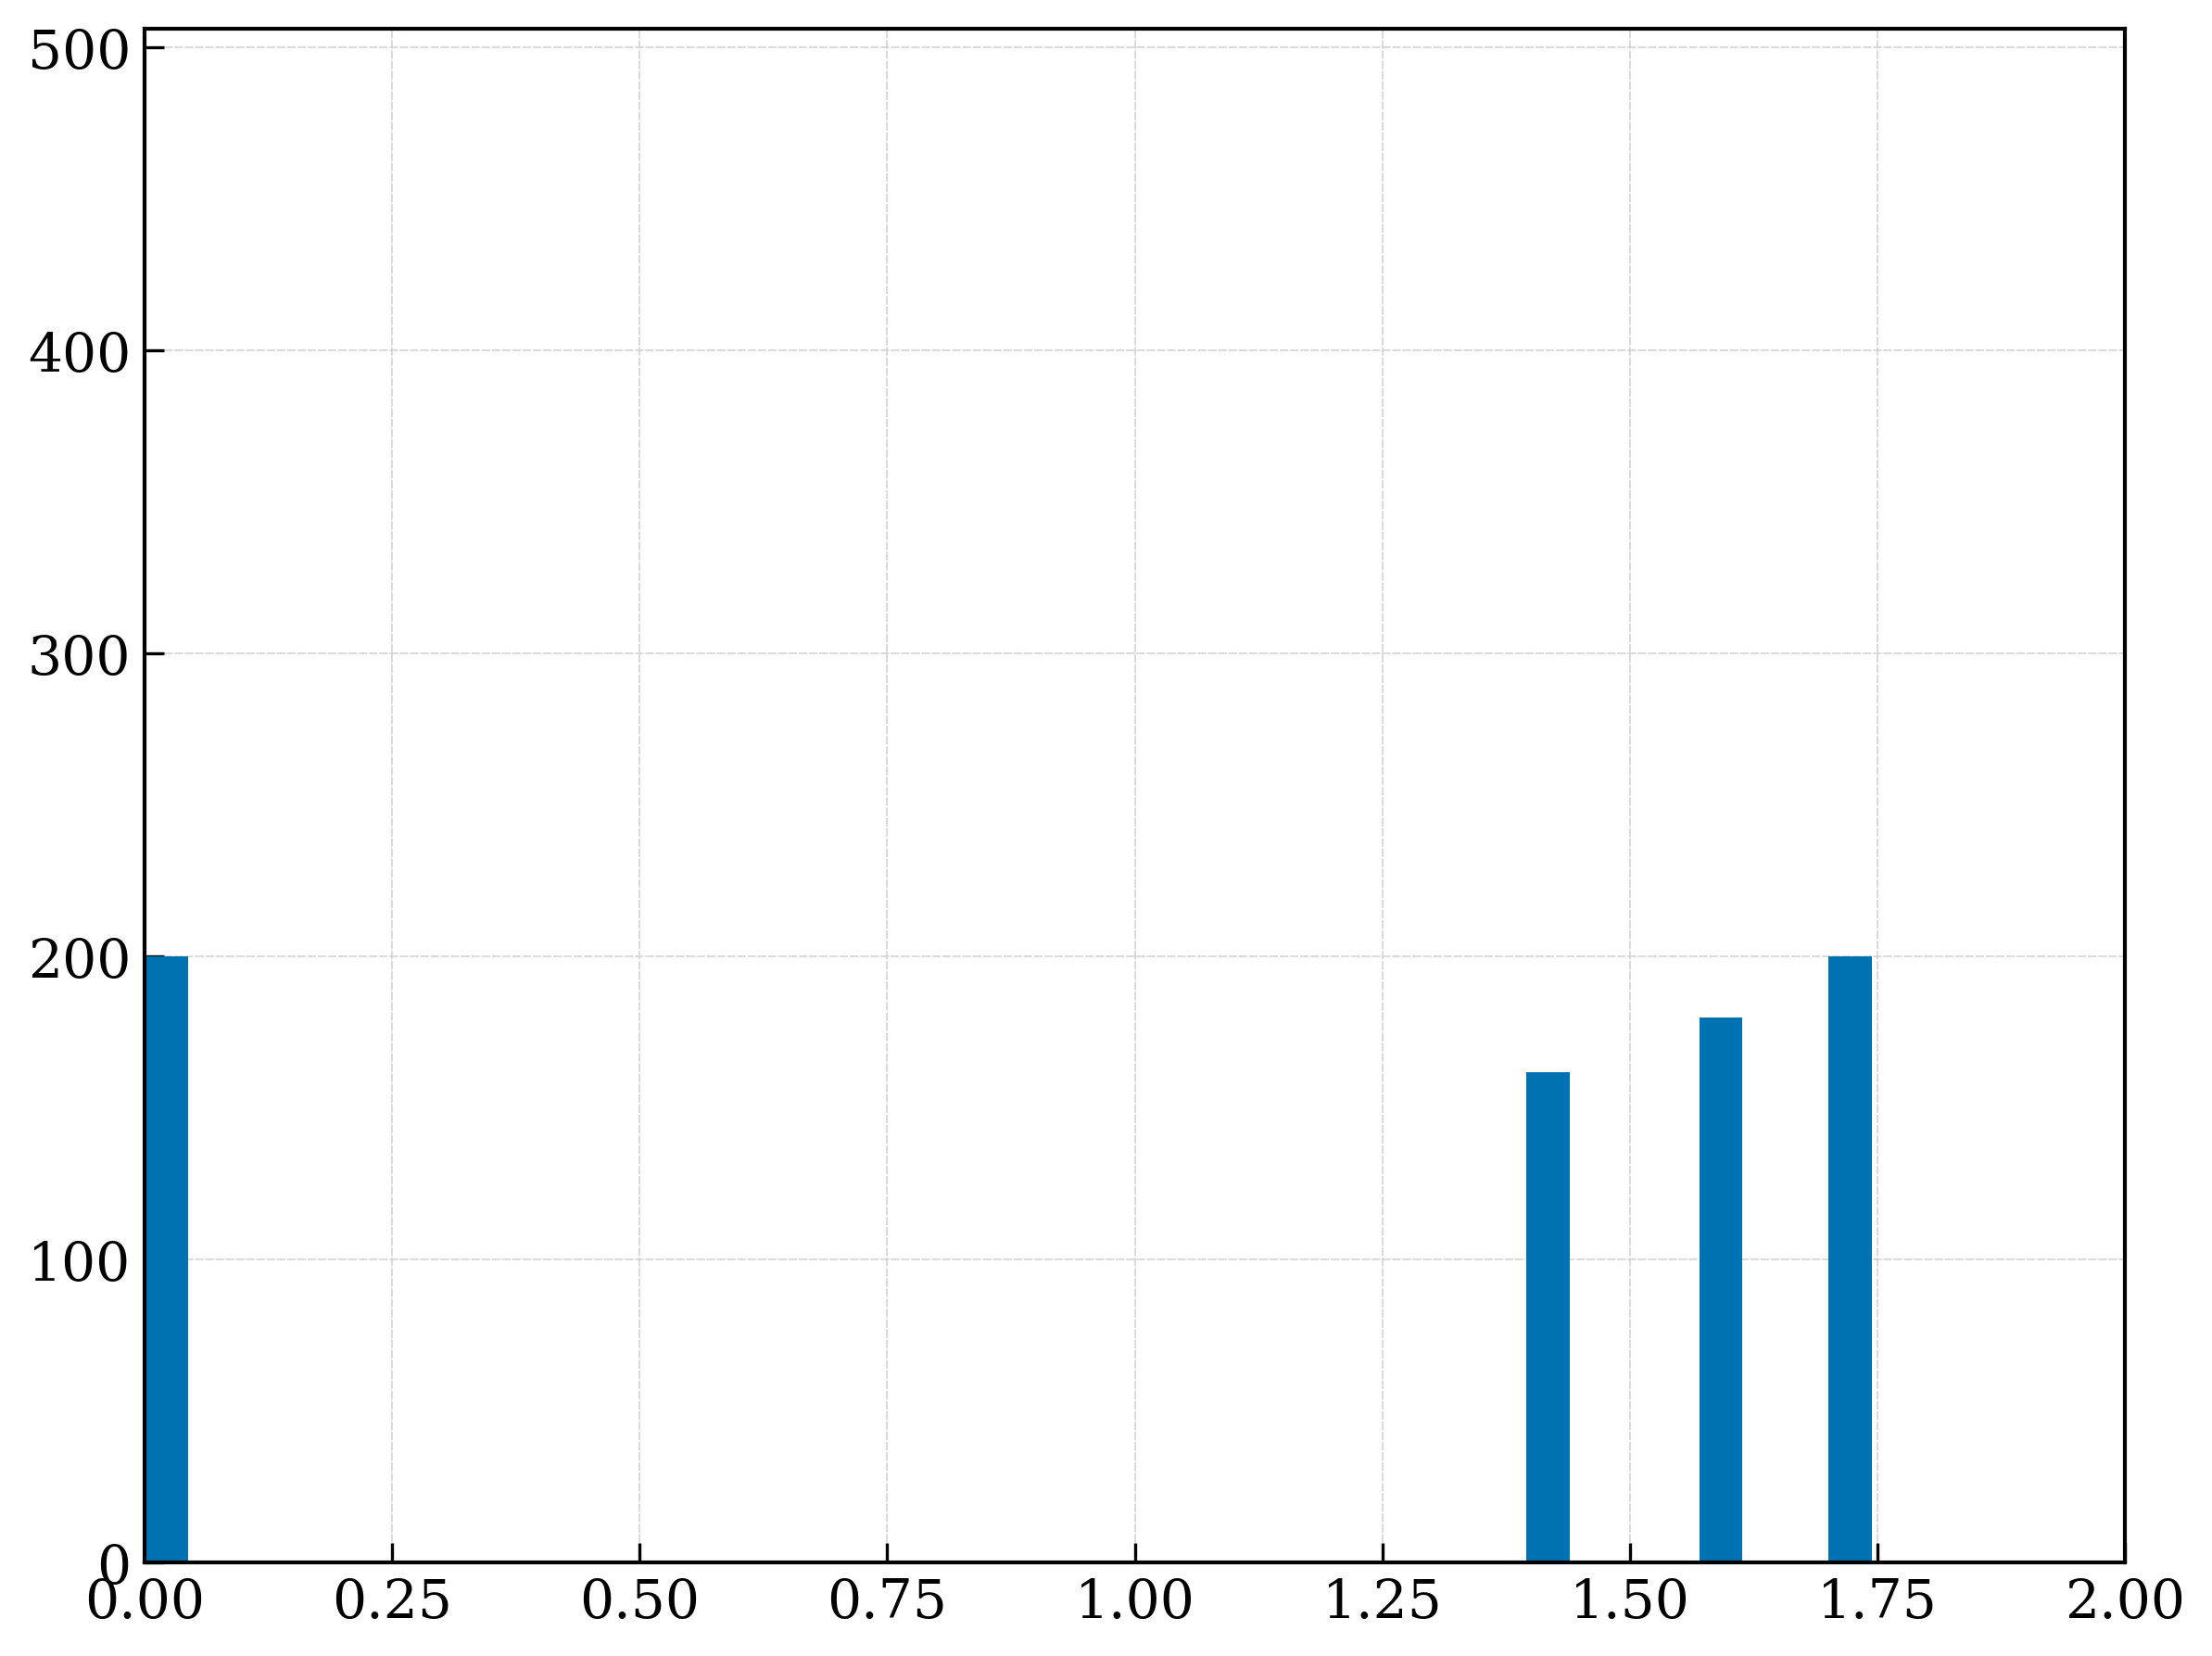

In [17]:
plt.hist(distances.flatten(), bins=1000);
plt.xlim((0, 2))

In [18]:
view(strained_atoms, viewer="x3d")

In [19]:
print(strained_atoms.get_positions())

[[-1.48542402e-08  1.97792404e-09  1.33431533e-20]
 [ 1.57693693e+00  7.11285122e-01  1.18041989e-20]
 [-1.23198198e+00  2.13385539e+00  1.33431533e-20]
 [ 3.44954967e-01  2.84514051e+00  1.18041989e-20]
 [-2.46396395e+00  4.26771077e+00  1.33431533e-20]
 [-8.87026999e-01  4.97899589e+00  1.18041989e-20]
 [-3.69594591e+00  6.40156616e+00  1.33431533e-20]
 [-2.11900897e+00  7.11285128e+00  1.18041989e-20]
 [-4.92792788e+00  8.53542154e+00  1.33431533e-20]
 [-3.35099093e+00  9.24670666e+00  1.18041989e-20]
 [-6.15990985e+00  1.06692769e+01  1.33431533e-20]
 [-4.58297290e+00  1.13805620e+01  1.18041989e-20]
 [-7.39189181e+00  1.28031323e+01  1.33431533e-20]
 [-5.81495487e+00  1.35144174e+01  1.18041989e-20]
 [-8.62387378e+00  1.49369877e+01  1.33431533e-20]
 [-7.04693683e+00  1.56482728e+01  1.18041989e-20]
 [-9.85585575e+00  1.70708431e+01  1.33431533e-20]
 [-8.27891880e+00  1.77821282e+01  1.18041989e-20]
 [-1.10878377e+01  1.92046985e+01  1.33431533e-20]
 [-9.51090077e+00  1.99159836e+

In [20]:
ND  = 100
DS = np.linspace(1.4, 3, num=ND)
Sforces0=[]
Sforces1=[]
Senergies=[]

strainedv0 = strained_positions[1] - strained_positions[0]
strainedv0 = strainedv0 / np.linalg.norm(strainedv0)
strainedCM = (strained_positions[1] + strained_positions[0]) / 2.0

for d in tqdm(DS):
    pos = strained_positions.copy()

    # keep center fixed
    pos[0] = strainedCM - 0.5*d*strainedv0
    pos[1] = strainedCM + 0.5*d*strainedv0

    strained_atoms.set_positions(pos)

    # evaluation
    E = strained_atoms.get_potential_energy()
    F = strained_atoms.get_forces()

    Senergies.append(E)
    Sforces0.append(F[0].copy())
    Sforces1.append(F[1].copy())


100%|██████████| 100/100 [00:02<00:00, 35.61it/s]


In [21]:
Sforces0=np.array(Sforces0).reshape((ND, 3))
Sforces1=np.array(Sforces1).reshape((ND, 3))
SEnergies = np.array(E)

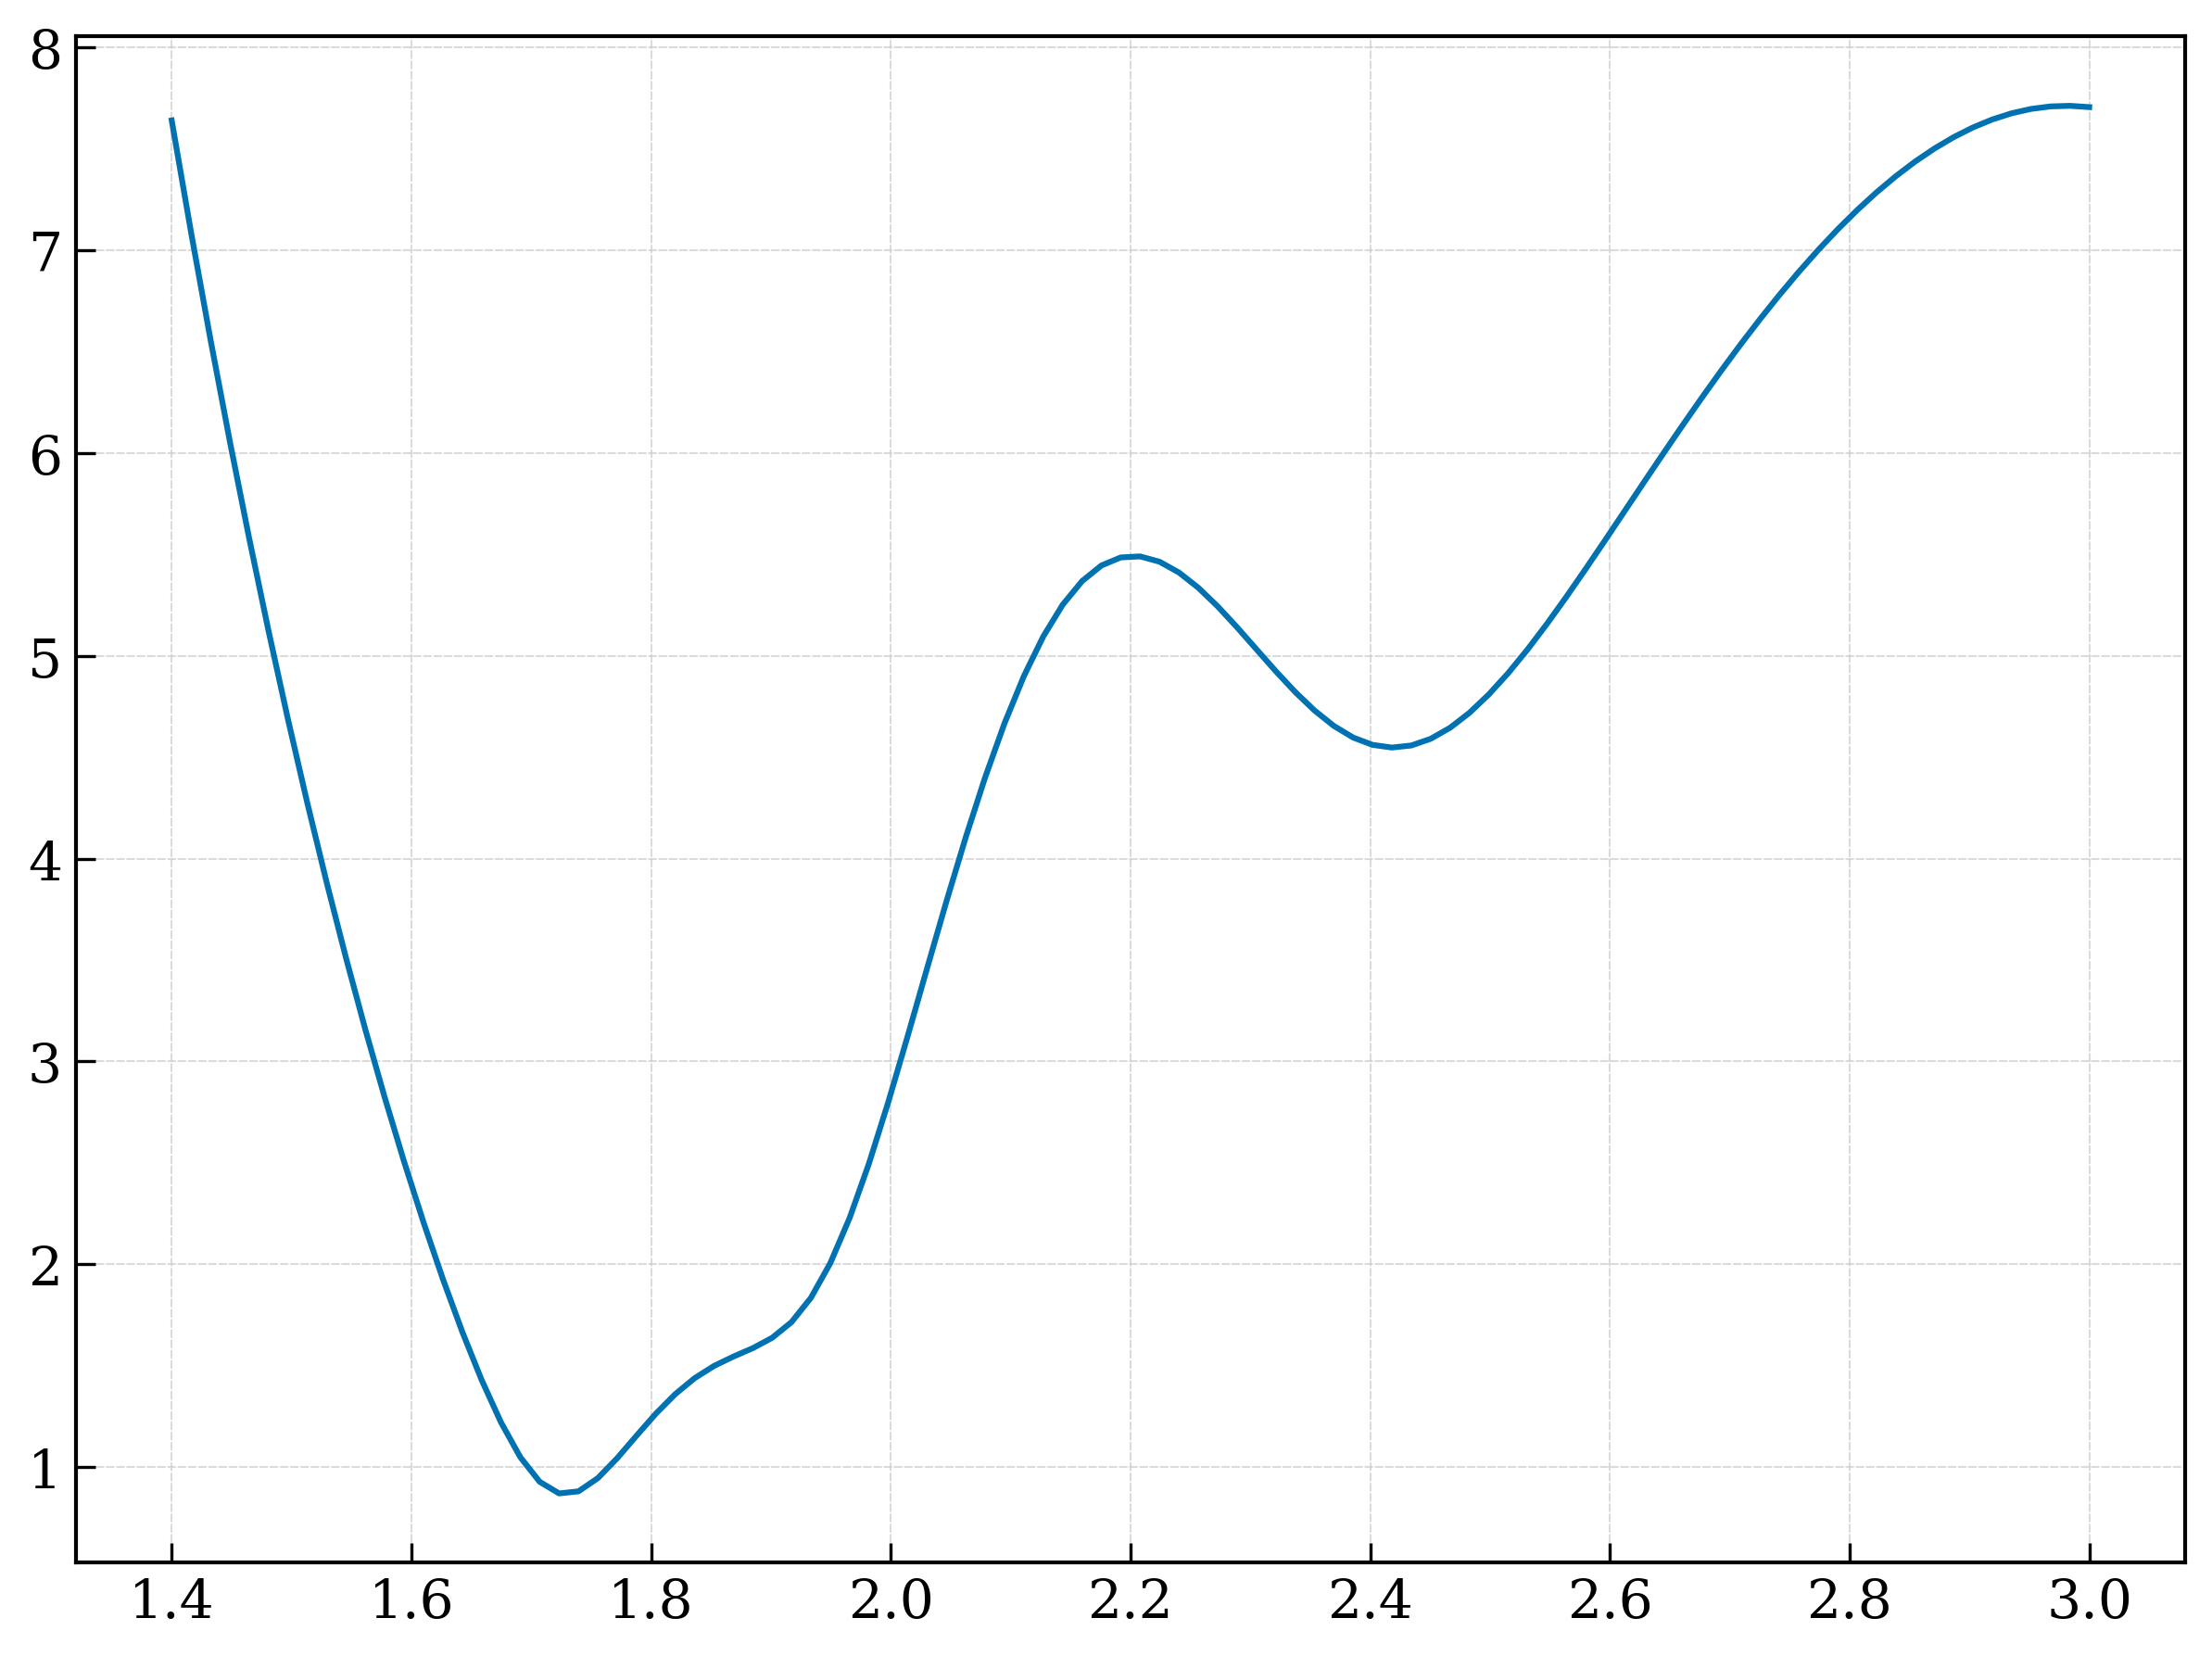

In [22]:
Sforces0norm = np.linalg.norm(Sforces0, axis=-1)
plt.plot(DS, Sforces0norm)

In [23]:
min_idx = np.argmin(Sforces0norm)

In [24]:
min_dist = DS[min_idx]
print(min_dist)

1.723232323232323
